# SeaSentinel: Tuhaf davranan gemileri bulmak

Gemiler AIS denen bir sistemle birkaç saniyede bir konumlarını, hızlarını ve adlarını yayınlıyor. Bu veri herkese açık.
Bu çalışmada Danimarka ile İsveç arasındaki Kattegat bölgesinde 3 günlük AIS verisine bakıp **basit kurallarla** tuhaf
davranan gemileri bulmaya çalıştım.

Denizcilik sektöründe staj yaptığım için gemi verisi ilgimi çekti.

Veri: Danimarka Denizcilik Otoritesi (http://aisdata.ais.dk/), 29 Eylül – 1 Ekim 2026. Sadece yük gemileri (Cargo) ve
tankerler (Tanker). Ham veri çok büyük olduğu için (günde ~5 GB) bölgeye göre süzülmüş ve gemi başına dakikada bir
noktaya indirilmiş halini kullanıyorum (`ais_kattegat.parquet`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Veriye ilk bakış

In [2]:
df = pd.read_parquet("ais_kattegat.parquet")
print(df.shape)
print("Gemi sayısı:", df["mmsi"].nunique())
print("Tarih aralığı:", df["zaman"].min(), "-", df["zaman"].max())
df.head()

(515164, 8)
Gemi sayısı: 507
Tarih aralığı: 2026-09-29 00:00:00 - 2026-10-01 23:59:58


,zaman,mmsi,enlem,boylam,durum,hiz,isim,gemi_tipi
0,2026-09-29 00:00:09,209525000,57.590220,9.826872,Under way using engine,7.6,NaN,Cargo
1,2026-09-29 00:01:09,209525000,57.591638,9.829863,Under way using engine,7.6,NaN,Cargo
2,2026-09-29 00:02:09,209525000,57.592998,9.832765,Under way using engine,7.6,NaN,Cargo
3,2026-09-29 00:03:09,209525000,57.594380,9.835755,Under way using engine,7.5,NaN,Cargo
4,2026-09-29 00:04:09,209525000,57.595747,9.838600,Under way using engine,7.5,NaN,Cargo


In [3]:
# Number of ships by type
df.groupby("gemi_tipi")["mmsi"].nunique()

gemi_tipi
Cargo     350
Tanker    157
Name: mmsi, dtype: int64

Elimizde 3 günde 507 gemiden (350 yük gemisi, 157 tanker) 515.164 konum kaydı var. Her satırda zaman, gemi numarası
(`mmsi`), enlem, boylam, hız (knot), gemi adı ve tipi bulunuyor.

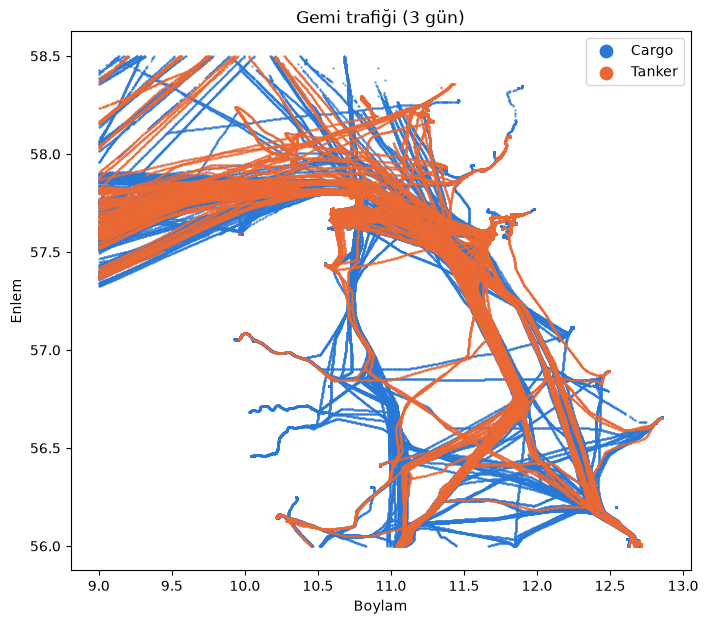

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
for ship_type, color in [("Cargo", "#2a78d6"), ("Tanker", "#eb6834")]:
    part = df[df["gemi_tipi"] == ship_type]
    ax.scatter(part["boylam"], part["enlem"], s=0.2, color=color, label=ship_type)
ax.set_title("Gemi trafiği (3 gün)")
ax.set_xlabel("Boylam")
ax.set_ylabel("Enlem")
ax.legend(markerscale=20)
plt.savefig("trafik_haritasi.png", dpi=120, bbox_inches="tight")
plt.show()

Haritada gemilerin geçtiği yollar net görünüyor. Kuzeyde Skagen'in etrafından dönen yoğun bir trafik var.
Tankerler (turuncu) özellikle Skagen ve Göteborg açıklarında yoğunlaşıyor.

## 2. Hazırlık

Kurallar için iki şeye ihtiyacım var:

- **İki nokta arası mesafe:** Enlem/boylamdan km hesaplamak için *haversine* formülünü kullandım (internette hazır
  bulunan standart bir formül).
- **Limanlar:** Limanda bağlı duran gemiler doğal olarak uzun süre durur ya da sinyal kesebilir. Bunları şüpheli saymamak
  için bölgedeki limanların yaklaşık konumlarını bir listeye yazdım.

Sonra her satır için geminin bir önceki sinyalinden bu yana geçen süreyi ve gittiği mesafeyi hesapladım.

In [5]:
def distance_km(lat1, lon1, lat2, lon2):
    # Haversine formula: distance between two points on Earth in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))


# Ports in the region: (name, latitude, longitude, radius in km)
PORTS = [
    ("Skagen", 57.718, 10.592, 3), ("Frederikshavn", 57.437, 10.548, 3.5),
    ("Sæby", 57.333, 10.530, 2), ("Hirtshals", 57.596, 9.963, 3),
    ("Aalborg", 57.050, 9.960, 6), ("Aalborg Portland", 57.055, 10.040, 3),
    ("Hals", 56.995, 10.310, 2), ("Randers", 56.460, 10.050, 4),
    ("Grenaa", 56.408, 10.925, 3), ("Aarhus", 56.150, 10.235, 5),
    ("Ebeltoft", 56.195, 10.680, 2), ("Læsø Vesterø", 57.297, 10.925, 2),
    ("Læsø Østerby", 57.318, 11.130, 2), ("Anholt", 56.716, 11.510, 2),
    ("Göteborg", 57.690, 11.880, 7), ("Marstrand", 57.887, 11.585, 2),
    ("Stenungsund", 58.070, 11.820, 4), ("Uddevalla", 58.350, 11.910, 4),
    ("Lysekil", 58.275, 11.435, 3), ("Brofjorden", 58.350, 11.420, 4),
    ("Varberg", 57.105, 12.245, 3), ("Falkenberg", 56.893, 12.490, 2.5),
    ("Halmstad", 56.665, 12.855, 3.5), ("Höganäs", 56.200, 12.552, 1.5),
    ("Helsingborg", 56.040, 12.695, 4), ("Helsingør", 56.035, 12.615, 2.5),
]


def in_port(lat, lon):
    # True if the point is inside one of the ports
    result = np.zeros(len(lat), dtype=bool)
    for name, p_lat, p_lon, radius in PORTS:
        result = result | (distance_km(lat, lon, p_lat, p_lon) <= radius)
    return result


# For every row, add the time and distance since the ship's previous signal
df = df.sort_values(["mmsi", "zaman"])
prev = df.groupby("mmsi")[["zaman", "enlem", "boylam"]].shift()
df["prev_time"] = prev["zaman"]
df["prev_lat"] = prev["enlem"]
df["prev_lon"] = prev["boylam"]
df["gap_hours"] = (df["zaman"] - df["prev_time"]).dt.total_seconds() / 3600
df["step_km"] = distance_km(df["prev_lat"], df["prev_lon"], df["enlem"], df["boylam"])

## 3. Kural 1: Sinyal kesme

Bir gemi **2 saatten uzun** süre hiç sinyal göndermediyse şüpheli sayıyorum. İki durumu hariç tuttum:
- Gemi bölgenin kenarındaysa bölgeden çıkıp geri girmiş olabilir.
- Gemi boşluğun iki ucunda da limandaysa sadece bağlı duruyordur.

In [6]:
gaps = df[df["gap_hours"] >= 2].copy()

# A ship near the edge of the area may have simply left the area and come back
near_edge = ((gaps["prev_lat"] < 56.2) | (gaps["prev_lat"] > 58.3) |
             (gaps["prev_lon"] < 9.2) | (gaps["prev_lon"] > 12.8))
# A ship that is in port at both ends of the gap is probably just docked
docked = in_port(gaps["prev_lat"], gaps["prev_lon"]) & in_port(gaps["enlem"], gaps["boylam"])
gaps = gaps[~near_edge & ~docked]

print(len(gaps), "sinyal kesme olayı")
gaps[["mmsi", "isim", "prev_time", "zaman", "gap_hours", "step_km"]].round({"gap_hours": 1, "step_km": 1})

6 sinyal kesme olayı


,mmsi,isim,prev_time,zaman,gap_hours,step_km
46056,219035786,BZL122 USV UNCREWED,2026-09-30 13:42:00,2026-10-01 08:20:01,18.6,25.6
150263,246873000,EEMS DUNDEE,2026-09-30 14:12:26,2026-10-01 15:33:26,25.4,24.3
276889,265793820,LIBRA,2026-09-29 04:09:02,2026-09-29 14:03:17,9.9,0.0
276923,265793820,NaN,2026-09-30 04:12:01,2026-09-30 09:41:15,5.5,0.2
277209,265793820,LIBRA,2026-10-01 04:49:17,2026-10-01 07:46:47,3.0,0.3
277216,265793820,LIBRA,2026-10-01 07:53:08,2026-10-01 14:10:22,6.3,0.0


6 olay çıktı. Bunların 4'ü **LIBRA** adlı aynı gemiye ait: Göteborg açığında 3 ile 10 saat arasında 4 kez sinyal göndermeyi
bırakmış ve bu sürede neredeyse hiç yer değiştirmemiş. **BZL122 USV UNCREWED** adındaki gemi ise adından da anlaşıldığı
gibi insansız bir tekne.

## 4. Kural 2: İmkânsız hız

İki sinyal arasındaki mesafeyi süreye bölerek geminin hızını hesapladım. Bir yük gemisi **40 knot**'tan (saatte ~74 km)
hızlı gidemez. Bundan hızlı görünüyorsa konum bilgisi ya hatalı ya da sahtedir.

In [7]:
df["speed_knots"] = df["step_km"] / 1.852 / df["gap_hours"]   # 1 nautical mile = 1.852 km

# Ignore tiny jumps under 1 km (normal GPS noise)
jumps = df[(df["speed_knots"] >= 40) & (df["step_km"] >= 1)]

print(len(jumps), "imkânsız hız olayı")
jumps[["mmsi", "isim", "prev_time", "zaman", "step_km", "speed_knots"]].round({"step_km": 1, "speed_knots": 0})

2 imkânsız hız olayı


,mmsi,isim,prev_time,zaman,step_km,speed_knots
21478,218019000,SEACOD,2026-09-29 19:23:25,2026-09-29 19:24:14,4.8,190.0
21479,218019000,SEACOD,2026-09-29 19:24:14,2026-09-29 19:25:14,4.3,138.0


2 olay çıktı, ikisi de **SEACOD** adlı gemide ve arka arkaya. Konum yaklaşık 1 dakikada 4,8 km sıçramış, bu ~190 knot demek.
Gerçek olamaz, büyük ihtimalle GPS ya da yayın hatası.

## 5. Kural 3: Yan yana durma

İki gemi açık denizde (limanda değil) uzun süre birbirine çok yakın ve neredeyse durur halde kalırsa, aralarında yük ya
da yakıt aktarılıyor olabilir.

Kural: İkisi de **3 knot'tan yavaş**, aralarında **500 metreden az** mesafe var ve bu durum toplamda **en az 1 saat**
sürmüş. Bunu kontrol etmek için zamanı 10 dakikalık dilimlere böldüm ve aynı dilimdeki gemi çiftlerinin mesafesine baktım.

In [8]:
# Ships that are almost stopped (under 3 knots) and not in a port
slow = df[(df["hiz"] < 3) & ~in_port(df["enlem"], df["boylam"])].copy()

# Split time into 10-minute slots and take each ship's average position per slot
slow["slot"] = slow["zaman"].dt.floor("10min")
slow = slow.groupby(["mmsi", "slot"], as_index=False)[["enlem", "boylam"]].mean()

# Pair every two ships that are in the same time slot
pairs = slow.merge(slow, on="slot", suffixes=("", "_2"))
pairs = pairs[pairs["mmsi"] < pairs["mmsi_2"]]
pairs["distance_m"] = 1000 * distance_km(pairs["enlem"], pairs["boylam"], pairs["enlem_2"], pairs["boylam_2"])
pairs = pairs[pairs["distance_m"] <= 500]

# How many 10-minute slots did each pair spend side by side?
side_by_side = (pairs.groupby(["mmsi", "mmsi_2"])
                .agg(slots=("slot", "count"), closest_m=("distance_m", "min"),
                     enlem=("enlem", "mean"), boylam=("boylam", "mean"))
                .reset_index())
side_by_side["minutes"] = side_by_side["slots"] * 10
side_by_side = side_by_side[side_by_side["minutes"] >= 60]

names = df.dropna(subset=["isim"]).groupby("mmsi")["isim"].first()
side_by_side["isim"] = side_by_side["mmsi"].map(names)
side_by_side["isim_2"] = side_by_side["mmsi_2"].map(names)

print(len(side_by_side), "yan yana durma olayı")
(side_by_side.sort_values("minutes", ascending=False)
 [["isim", "isim_2", "minutes", "closest_m"]].head(10).round(0))

55 yan yana durma olayı


,isim,isim_2,minutes,closest_m
46,ANNA LORD,SVEA,840,85.0
10,COPENHAGEN,MONTAUK,720,16.0
8,AMAK SWAN,MEGHNA SPIRIT,650,25.0
48,LOTE,SVEA,570,166.0
15,COPENHAGEN,ARAUCARIA,480,23.0
36,SINDRE KNUTSEN,SAGAFJORD,470,24.0
13,COPENHAGEN,KWAI KWAI,460,27.0
20,ROTMISTRZ WITOLD PIL,VINGAREN,440,63.0
0,FEZZAN,VINGAREN,420,86.0
42,VINGAREN,RAINBOW SPIRIT,400,54.0


55 gemi çifti bu kurala takıldı. En uzun süre yan yana duran çift (ANNA LORD ve SVEA) toplamda 14 saat yakın kalmış; en yakın anda
aralarında sadece 85 metre varmış.

## 5. Sonuçlar

In [9]:
events = pd.concat([
    pd.DataFrame({"olay": "Sinyal kesme", "mmsi": gaps["mmsi"],
                  "enlem": gaps["prev_lat"], "boylam": gaps["prev_lon"]}),
    pd.DataFrame({"olay": "İmkânsız hız", "mmsi": jumps["mmsi"],
                  "enlem": jumps["prev_lat"], "boylam": jumps["prev_lon"]}),
    pd.DataFrame({"olay": "Yan yana durma", "mmsi": side_by_side["mmsi"],
                  "enlem": side_by_side["enlem"], "boylam": side_by_side["boylam"]}),
], ignore_index=True)
events["isim"] = events["mmsi"].map(names)
events.to_csv("olaylar.csv", index=False)

counts = events["olay"].value_counts()
print(counts)
print("Toplam:", len(events), "olay,", events["mmsi"].nunique(), "farklı gemi")

olay
Yan yana durma    55
Sinyal kesme       6
İmkânsız hız       2
Name: count, dtype: int64
Toplam: 63 olay, 30 farklı gemi


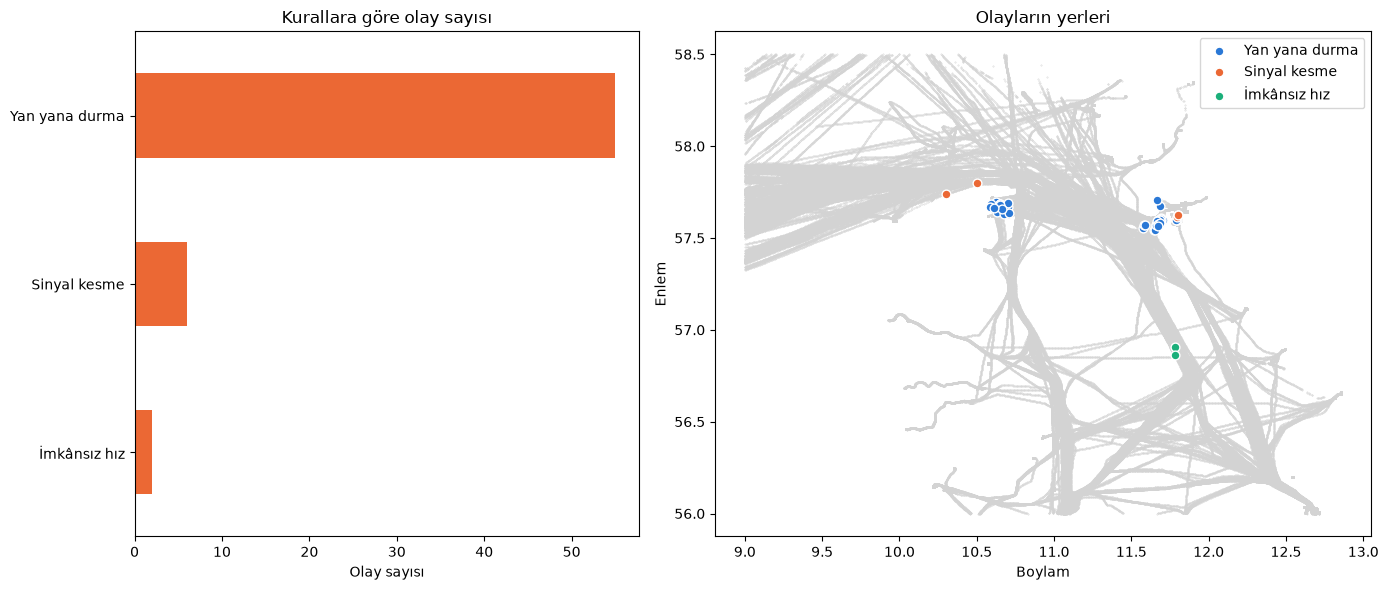

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.3]})

counts.sort_values().plot(kind="barh", ax=axes[0], color="#eb6834")
axes[0].set_title("Kurallara göre olay sayısı")
axes[0].set_xlabel("Olay sayısı")
axes[0].set_ylabel("")

axes[1].scatter(df["boylam"], df["enlem"], s=0.1, color="lightgray")
for event_type, color in [("Yan yana durma", "#2a78d6"), ("Sinyal kesme", "#eb6834"), ("İmkânsız hız", "#1baf7a")]:
    part = events[events["olay"] == event_type]
    axes[1].scatter(part["boylam"], part["enlem"], s=40, color=color, label=event_type, edgecolors="white")
axes[1].set_title("Olayların yerleri")
axes[1].set_xlabel("Boylam")
axes[1].set_ylabel("Enlem")
axes[1].legend()

plt.tight_layout()
plt.savefig("olaylar.png", dpi=120, bbox_inches="tight")
plt.show()

Toplam **63 olay** ve **30 farklı gemi** var. Olayların büyük çoğunluğu (55) "yan yana durma" ve haritada görüldüğü
gibi neredeyse hepsi iki bölgede toplanıyor: **Skagen açığı** ve **Göteborg açığı**.

In [11]:
# Ships with the most events
events.groupby(["mmsi", "isim"]).size().sort_values(ascending=False).head(10)

mmsi       isim                
219355000  AMAK SWAN               6
220614000  COPENHAGEN              6
265012140  VINGAREN                5
266203000  FOX SUNRISE             5
256717000  NORE                    5
265550210  TANKSKAR                4
265793820  LIBRA                   4
228432600  GORDONWATERS KNUTSEN    3
265525670  ANNA LORD               2
219019067  GAIA NORDIC             2
dtype: int64

En çok olaya karışan gemilerin hepsi **tanker** (AMAK SWAN, COPENHAGEN, VINGAREN, FOX SUNRISE, NORE). Bu bölgelerde
demirli gemilere yakıt veren tankerler olabilir. Yani kural doğru davranışı buluyor ama bu işlerin çoğu büyük
ihtimalle tamamen yasal: yan yana durmak tek başına "şüpheli" demek değil.

## Sonuç

- 3 basit kuralla 3 günde 63 olay buldum.
- En çok görülen olay "yan yana durma" (55). Çoğunda tankerler var ve olaylar Skagen ile Göteborg açıklarında toplanıyor.
- Sinyal kesmede öne çıkan gemi LIBRA (4 kez), imkânsız hızda SEACOD (konum 4,8 km sıçramış).
- Olaylar `olaylar.csv` dosyasında; Excel ya da Power BI ile açılabilir.

## Eksikler

- Sadece 3 günlük veri ve tek bir bölge kullandım.
- Gemiler AIS'e bilgilerini kendileri giriyor, gemi adı ya da tipi yanlış olabilir.
- Kuralların eşikleri (2 saat, 40 knot, 500 metre, 1 saat) benim seçtiğim değerler. Farklı eşiklerle sonuçlar değişir.
- Elimde "bu gemi gerçekten şüpheliydi" diye işaretlenmiş bir liste olmadığı için kuralların ne kadar doğru olduğunu ölçemedim.
- Bir olay bulunması geminin suç işlediği anlamına gelmiyor, sadece "buna bir bakmak lazım" demek.